# ARI5121 – Applied NLP | Speech Analysis and Evaluation Project

This notebook implements a speaker voice `similarity analysis pipeline` for the **speech processing component for the ARI5121 Applied NLP**. The aim of which, is to evaluate how well a pre-trained WavLM speaker verification model can distinguish between same-speaker and different-speaker audio pairs.

The notebook uses the **ABI-1 Corpus** and focuses only on the `shortpassage` WAV files. These audio files are first extracted into a cleaned folder structure, then indexed using a metadata CSV file. The metadata stores the accent, gender, speaker ID, and file path for each selected WAV file.

The main processing stage uses the `microsoft/wavlm-base-plus-sv` model to extract one speaker embedding per WAV file. These embeddings are then compared using cosine similarity. For this, a threshold-based decision rule is used, were pairs with cosine similarity above the selected threshold are classified as the same speaker, while pairs below the threshold are classified as different speakers.

The notebook also evaluates the system using **threshold testing, accuracy, precision, recall, specificity, F1 score, confusion matrices** and visualisations such as **PCA** and **t-SNE plots**.

## 0. Setup

This section imports the libraries required for file handling, audio loading, model inference, evaluation and visualisation.

The main libraries used are:

- `librosa` for loading and resampling WAV files.
- `torch` and `transformers` for loading and running the WavLM model.
- `pandas` and `numpy` for storing metadata, embeddings, and results.
- `scikit-learn` for evaluation metrics, PCA, and t-SNE.
- `matplotlib` for plotting results.

In [1]:
import time

# File handling
import shutil
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
from itertools import combinations

# Audio loading
import librosa

# Deep learning / Hugging Face
import torch
import torch.nn.functional as F
from transformers import AutoFeatureExtractor, AutoModelForAudioXVector

# Evaluation and visualisation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

/home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0.1. Config Parameters

The configuration parameters in this subsection define the model name, target sample rate, device, dataset paths, and output folders.

In [2]:
MODEL_NAME = "microsoft/wavlm-base-plus-sv"
TARGET_SAMPLE_RATE = 16000

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f">> [OK] Device Selected: {DEVICE}")

CORPUS_DIR = Path("../ABI-1 Corpus")
OUTPUT_DIR = Path("../extracted_wavs")
RESULTS_DIR = Path("../results")

>> [OK] Device Selected: cuda


### 0.2. Execution Timer

In [3]:
start_time = time.time()

## 1. Validate Corpus Existence

This section checks that the ABI-1 Corpus folder exists before any processing begins. This is implemented in the pipeline, since it prevents later stages from failing due to an incorrect or missing dataset path.

The validation function checks both whether the path exists and whether it points to a folder. If either check fails, an error is raised with the expected location.

In [4]:
# validate corpus
def validate_corpus_folder(corpus_dir):
    """
    Checks that the ABI-1 corpus folder exists inside the project directory
    """

    if not corpus_dir.exists():
        raise FileNotFoundError(
            f">> [ERROR] Corpus folder not found.\n"
            f"Expected location:\n{corpus_dir.resolve()}\n\n"
            f"Make sure the ABI-1 corpus folder is inside your project directory."
        )

    if not corpus_dir.is_dir():
        raise NotADirectoryError(
            f">> [ERROR] Corpus path exists, but it is not a folder:\n{corpus_dir.resolve()}"
        )

    print(f">> [OK] Corpus folder found: {corpus_dir.resolve()}")

In [5]:
validate_corpus_folder(CORPUS_DIR)

>> [OK] Corpus folder found: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/ABI-1 Corpus


## 2. Extract shortpassage WAV files

This section filters the ABI-1 Corpus, because only the `shortpassage` WAV files are used in this pipeline. The assignment does not require the transcription .TRS or .TXT files, so they are excluded from the cleaned dataset.

The selected WAV files are copied into a new output folder `(extracted_wavs)` while preserving the original folder structure. Keeping the folder structure is useful because information such as accent, gender, and speaker ID can still be extracted from the file path and traced back to the original ABI-1 Corpus directory if needed.

**This step also makes the rest of the notebook easier to manage because only the required audio files are processed.**

In [ ]:
def extract_shortpassage_waves(corpus_dir, output_dir):
    """
    Copies only the required shortpassage .wav files into a cleaned folder
    """
    
    # create output dir if it doesn't exists
    output_dir.mkdir(parents=True, exist_ok=True)
    
    copied_count = 0
    skipped_count = 0
    
    for file_path in corpus_dir.rglob("*.wav"):
        # Check is a .wav file has shortpassage in the name
        is_shortpassage = "shortpassage" in file_path.name.lower()
        
        if not is_shortpassage:
            skipped_count += 1
            continue

        # Get path relative to the original corpus folder
        relative_path = file_path.relative_to(corpus_dir)
        # Copy into cleaned folder while preserving folder structure
        destination_path = output_dir / relative_path
        # Create destination parent folders
        destination_path.parent.mkdir(parents=True, exist_ok=True)

        # Copy file
        shutil.copy2(file_path, destination_path)
        copied_count += 1
        # print(f">> [COPIED] {relative_path}")

    print(">> --- [CLEANING COMPLETE] --- :")
    print(f">> WAV files copied: {copied_count}")
    print(f">> Files skipped: {skipped_count}")
    print(f">> Cleaned folder: {output_dir.resolve()}")

In [7]:
if OUTPUT_DIR.exists():
    print(f">> [INFO] Extracted .WAV files found: {OUTPUT_DIR.resolve()}")
    print(">> [INFO] Skipping .WAV file extraction")
else:
    extract_shortpassage_waves(CORPUS_DIR, OUTPUT_DIR)

>> --- [CLEANING COMPLETE] --- :
>> WAV files copied: 855
>> Files skipped: 1995
>> Cleaned folder: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/extracted_wavs


## 3. Create a metadata CSV

This section creates a metadata CSV file for the cleaned WAV files. Each row stores the `accent, gender, speaker ID` and `full file path` for one audio sample.

The metadata file acts as an index for the dataset. Although the WAV files could be scanned directly from the folder each time, using a metadata file makes the pipeline easier to rerun and reduces the need to repeatedly parse the folder structure.

This is especially useful in later stages because embedding extraction can simply loop through the metadata table rather than searching for files again.

In [8]:
metadata_path = OUTPUT_DIR / "metadata.csv"

def create_metadata(cleaned_dir):
    """
    Creates a metadata CSV from the cleaned WAV folder
    """

    records = []

    for wav_path in cleaned_dir.rglob("*.wav"):
        relative_parts = wav_path.relative_to(cleaned_dir).parts
        # print(relative_parts)     # Structure is ('accents', 'crn_001', 'female', 'lms002', 'shortpassagea_CT.wav')

        if len(relative_parts) < 5:
            print(f">> [WARNING] Unexpected path structure: {relative_parts}")
            continue

        accent = relative_parts[1]
        gender = relative_parts[2]
        speaker_id = relative_parts[3]

        records.append({
            "accent": accent,
            "gender": gender,
            "speaker_id": speaker_id,
            "file_path": str(wav_path.resolve())
        })

    # Create DataFrame
    metadata_df = pd.DataFrame(records)
    # Save to csv
    metadata_df.to_csv(metadata_path, index=False)

    print(f">> [OK] Metadata created: {metadata_path.resolve()}")
    print(f">> [INFO] Number of WAV files: {len(metadata_df)}")
    print(f">> [INFO] Number of speakers: {metadata_df['speaker_id'].nunique()}")

    return metadata_df

**NOTE:** Several sections in this notebook use `if checks` to determine whether an output file already exists. This is done so that time-consuming stages, such as extracting speaker embeddings or computing pairwise cosine similarities, do not need to be repeated every time the notebook is rerun.

If an output file already exists, the notebook loads the saved file and skips that processing step. If the file does not exist, the notebook runs the full process and saves the result for future use. **This makes the workflow easier to test section by section and helps avoid unnecessary recomputation.**

In [9]:
if metadata_path.exists():
    print(f">> [INFO] Existing metadata file found: {metadata_path.resolve()}")
    print(">> [INFO] Skipping metadata creation")
    metadata_df = pd.read_csv(metadata_path)
else:
    metadata_df = create_metadata(OUTPUT_DIR)

>> [OK] Metadata created: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/extracted_wavs/metadata.csv
>> [INFO] Number of WAV files: 855
>> [INFO] Number of speakers: 284


## 4. Load WavLM

This section loads the pre-trained WavLM speaker verification model `(microsoft/wavlm-base-plus-sv)`. The model used is designed to produce speaker embeddings from speech audio.

The feature extractor prepares the raw audio in the format expected by the model. The model then generates fixed-length speaker embeddings from the processed audio.

The model is moved to GPU if CUDA is available; otherwise, it runs on CPU. It is also placed in evaluation mode because the notebook only performs inference and does not train the model.

In [10]:
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)    # Load the feature extractor for the WavLM-sv model
model = AutoModelForAudioXVector.from_pretrained(MODEL_NAME)            # Load the pre-trained WavLM-sv model

model = model.to(DEVICE)
model.eval()

print(f">> [OK] Model loaded: {MODEL_NAME}")
print(f">> [INFO] Device: {DEVICE}")

Loading weights: 100%|██████████| 266/266 [00:00<00:00, 14417.14it/s]


>> [OK] Model loaded: microsoft/wavlm-base-plus-sv
>> [INFO] Device: cuda


## 5. Extract Speaker Embeddings

This section extracts speaker embeddings from the selected WAV files using the WavLM speaker verification model. The process is split into two parts: first, a helper function is defined to extract an embedding from one audio file; then, this function is applied to all WAV files listed in the metadata table.

### 5.1 Embedding Extraction Function

The audio file is loaded with `librosa`, converted to mono, and resampled to `16 kHz`. It is then passed through the WavLM feature extractor so that it matches the input format expected by the model.

The processed audio is passed through the WavLM model without calculating gradients, since the model is only used for inference. The output embedding is moved back to the CPU and returned for later storage.

**NOTE:** `16 kHz` was used, since the model was pre-trained on speech audio sampled at 16 kHz, and the [**documentation page**](https://huggingface.co/microsoft/wavlm-base-plus-sv?utm_source=chatgpt.com) explicitly says that when using the model, the speech input should also be sampled at `16 kHz`.

In [11]:
def extract_embedding(file_path):
    """
    Loads a WAV file and extracts a speaker embedding using WavLM
    """
    
    # Load and resample audio to 16 kHz
    audio, sample_rate = librosa.load(file_path, sr=TARGET_SAMPLE_RATE, mono=True)

    # Prepare audio for the model
    inputs = feature_extractor(audio, sampling_rate=sample_rate, return_tensors="pt", padding=True)

    # Move inputs to selected device
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

    # Extract embedding without calculating gradients
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract the single embedding vector and move it back to CPU
    embedding = outputs.embeddings[0].cpu()

    return embedding

### 5.2 Extract and Save Embeddings for All WAV Files

In this subsection before running the extraction process, the notebook checks whether a saved embeddings file already exists. If it exists, the file is loaded and the extraction step is skipped as mentioned previously.

If no saved file exists, the notebook loops through each row in the metadata table, extracts the speaker embedding, and stores it together with the accent, gender, speaker ID, and file path. The final embeddings table is saved as a pickle file so that later stages, such as cosine similarity comparison and visualisation, can reuse it directly.

In [12]:
embedding_output_path = RESULTS_DIR / "speaker_embeddings.pkl"

if embedding_output_path.exists():
    print(f">> [INFO] Existing embeddings found: {embedding_output_path.resolve()}")
    print(">> [INFO] Skipping embedding extraction")
    embedding_df = pd.read_pickle(embedding_output_path)
else:

    embedding_records = []
    failed_files = []

    # Loop through every WAV file listed in the metadata table
    for index, row in metadata_df.iterrows():
        file_path = row["file_path"]

        try:
            # Extract one speaker embedding from the current WAV file
            embedding = extract_embedding(file_path)

            # Store the embedding together with its metadata
            embedding_records.append({
                "accent": row["accent"],
                "gender": row["gender"],
                "speaker_id": row["speaker_id"],
                "file_path": file_path,
                "embedding": embedding.numpy()
            })

            print(f">> [OK] Extracted embedding {index + 1}/{len(metadata_df)}", end="\r", flush=True)

        except Exception as error:
            # Store files that failed during embedding extraction
            failed_files.append({
                "file_path": file_path,
                "error": str(error)
            })

            print(f">> [ERROR] Failed to extract embedding for: {file_path}")
            print(error)

    # Convert to DataFrame
    embedding_df = pd.DataFrame(embedding_records)
    # Create results directory
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    # Save embeddings to .pkl file
    embedding_df.to_pickle(embedding_output_path)

    print(f">> [OK] Speaker embeddings saved to: {embedding_output_path.resolve()}")
    print(f">> [INFO] Successful embeddings: {len(embedding_df)}")
    print(f">> [INFO] Failed files: {len(failed_files)}")

/home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/.venv/lib/python3.12/site-packages/torch/nn/functional.py:6441: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = _canonical_mask(


>> [OK] Speaker embeddings saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/speaker_embeddings.pkl
>> [INFO] Successful embeddings: 855
>> [INFO] Failed files: 0


## 6. Pairwise Cosine Similarities

This section compares every `unique pair` of speaker embeddings using cosine similarity. Each comparison produces a similarity score between two audio samples.

Additionally, for each pair, the notebook stores whether the two files belong to the same speaker which becomes the ground-truth label used during threshold evaluation.

**The pairwise similarity results are then saved to a pickle file. This avoids repeating computation when testing and visualising different thresholds.**

In [13]:
similarity_output_path = RESULTS_DIR / "pairwise_similarities.pkl"

if similarity_output_path.exists():
    print(f">> [INFO] Existing pairwise similarities found: {similarity_output_path.resolve()}")
    print(">> [INFO] Skipping pairwise comparison")
    similarity_df = pd.read_pickle(similarity_output_path)
else:

    similarity_records = []

    # Calculate the total number of unique pairs - For n embeddings, the number of pairs is n * (n - 1) / 2
    total_pairs = len(embedding_df) * (len(embedding_df) - 1) // 2

    # Compare every unique pair of embeddings - combinations(..., 2) avoids comparing a file with itself and avoids duplicate comparisons
    for pair_index, (idx1, idx2) in enumerate(combinations(embedding_df.index, 2), start=1):
        # Get the two rows being compared.
        row1 = embedding_df.loc[idx1]
        row2 = embedding_df.loc[idx2]

        # Convert the saved NumPy embeddings back into PyTorch tensors
        embedding_1 = torch.tensor(row1["embedding"])
        embedding_2 = torch.tensor(row2["embedding"])

        # Compute cosine similarity between the two speaker embeddings - high scores are better
        similarity = F.cosine_similarity(
            embedding_1,
            embedding_2,
            dim=0
        ).item()

        # Check if the two files belong to the same speaker - Ground-Truth label for comparison
        same_speaker = row1["speaker_id"] == row2["speaker_id"]

        # Store results
        similarity_records.append({
            "file_path_1": row1["file_path"],
            "file_path_2": row2["file_path"],
            "speaker_id_1": row1["speaker_id"],
            "speaker_id_2": row2["speaker_id"],
            "same_speaker": same_speaker,
            "cosine_similarity": similarity
        })

        print(f">> [INFO] Compared pair {pair_index}/{total_pairs}", end="\r", flush=True)

    # Convert to DataFrame
    similarity_df = pd.DataFrame(similarity_records)
    # Save Results to a .pkl file
    similarity_df.to_pickle(similarity_output_path)

    print(f"\n>> [OK] Pairwise similarities saved to: {similarity_output_path.resolve()}")
    print(f">> [INFO] Total comparisons: {len(similarity_df)}")

>> [INFO] Compared pair 365085/365085
>> [OK] Pairwise similarities saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/pairwise_similarities.pkl
>> [INFO] Total comparisons: 365085


## 7. Evaluate Cosine Similarity Thresholds

In this section different cosine similarity thresholds are evaluated. A pair is predicted as the same speaker `if` its cosine similarity is greater than or equal to the threshold. `Else`, it is predicted as a different-speaker pair.

A refined threshold range `(np.arange(0.90, 1.001, 0.01))` is used because earlier testing showed that the best performance occurred at higher threshold values `(0.95)`. Testing stricter thresholds helps refine the cut-off point between same-speaker and different-speaker pairs.

For each threshold, the notebook calculates accuracy and confusion matrix values. The best threshold is selected based on the highest accuracy and it is then used for the final evaluation.

In [14]:
threshold_results = []

# Thresholds to test
# thresholds = np.arange(0.50, 0.96, 0.05)
thresholds = np.arange(0.90, 1.001, 0.01)

for threshold in thresholds:
    # Predict same speaker if cosine similarity is above the threshold
    similarity_df["predicted_same_speaker"] = similarity_df["cosine_similarity"] >= threshold

    # True labels
    y_true = similarity_df["same_speaker"]

    # Predicted labels
    y_pred = similarity_df["predicted_same_speaker"]

    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Calculate confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "true_positive": tp,
        "false_positive": fp,
        "false_negative": fn,
        "true_negative": tn
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_output_path = RESULTS_DIR / "threshold_results.csv"
threshold_results_df.to_csv(threshold_output_path, index=False)

print(f">> [OK] Threshold results saved to: {threshold_output_path.resolve()}")
threshold_results_df

>> [OK] Threshold results saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/threshold_results.csv


,threshold,accuracy,true_positive,false_positive,false_negative,true_negative
0,0.90,0.882312,855,42957,9,321264
1,0.91,0.908843,855,33271,9,330950
2,0.92,0.933443,855,24290,9,339931
3,0.93,0.955052,855,16401,9,347820
4,0.94,0.972817,855,9915,9,354306
5,0.95,0.985836,855,5162,9,359059
6,0.96,0.994300,855,2072,9,362149
7,0.97,0.998335,855,599,9,363622
8,0.98,0.999688,849,99,15,364122
9,0.99,0.999617,724,0,140,364221


In [15]:
best_result = threshold_results_df.sort_values(
    by="accuracy", # accuracy was chosen as it was highlighted in the project description
    ascending=False
).iloc[0]

best_threshold = best_result["threshold"]

print(f">> [OK] Best threshold: {best_threshold:.2f}")
print(f">> [INFO] Best accuracy: {best_result['accuracy']:.6f}")

>> [OK] Best threshold: 0.98
>> [INFO] Best accuracy: 0.999688


### 7.1 Threshold Accuracy Plot

In [16]:
PLOTS_PATH = RESULTS_DIR / f"plots_bestThreshold_{best_threshold:.2f}" 
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

This plot shows how accuracy changes as the cosine similarity threshold increases. It helps identify which threshold gives the strongest overall performance.

In this experiment, higher thresholds improved the results because they reduced false matches between different speakers. This supports the use of a stricter threshold for the final decision rule.

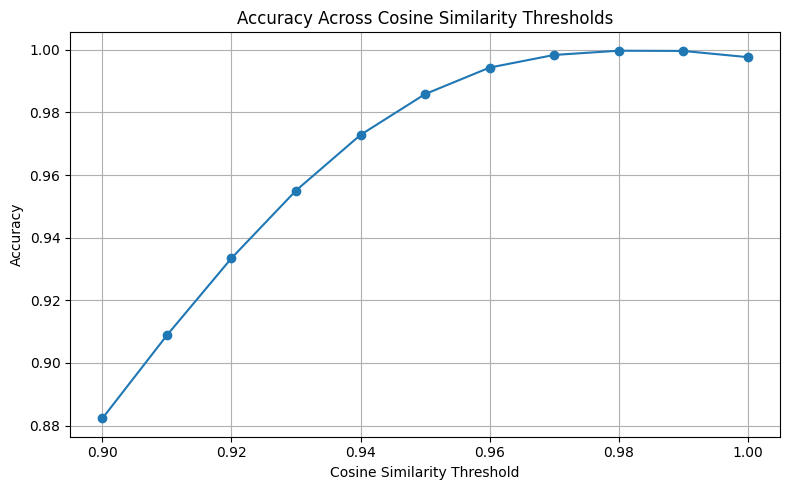

>> [OK] Threshold accuracy plot saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/plots_bestThreshold_0.98/threshold_accuracy_plot.png


In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["accuracy"],
    marker="o"
)

plt.title("Accuracy Across Cosine Similarity Thresholds")
plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.tight_layout()

threshold_plot_path = PLOTS_PATH / "threshold_accuracy_plot.png"
plt.savefig(threshold_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f">> [OK] Threshold accuracy plot saved to: {threshold_plot_path.resolve()}")

### 7.2 Cosine Similarity Distribution

These plots show how cosine similarity scores are distributed for same-speaker and different-speaker pairs. This helps visualise how well the embedding scores separate the two classes.

#### 7.2.1 Frequency VS Cosine Similarity

The frequency plot shows the actual number of comparisons in each score range. Since there are far more different-speaker pairs than same-speaker pairs, the different-speaker distribution dominates the plot.

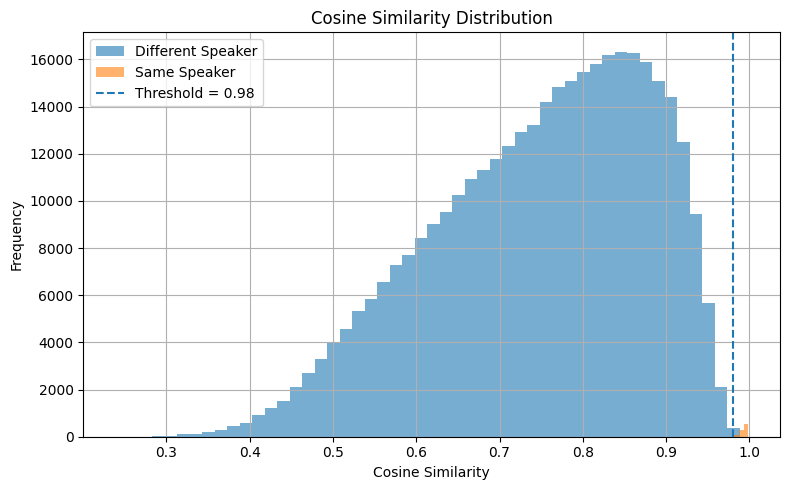

>> [OK] Similarity distribution plot saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/plots_bestThreshold_0.98/cosine_similarity_distribution_frequency.png


In [18]:
same_scores = similarity_df[similarity_df["same_speaker"] == True]["cosine_similarity"]
different_scores = similarity_df[similarity_df["same_speaker"] == False]["cosine_similarity"]

plt.figure(figsize=(8, 5))

plt.hist(different_scores, bins=50, alpha=0.6, label="Different Speaker")
plt.hist(same_scores, bins=50, alpha=0.6, label="Same Speaker")

plt.axvline(best_threshold, linestyle="--", label=f"Threshold = {best_threshold:.2f}")

plt.title("Cosine Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()

distribution_freq_plot_path = PLOTS_PATH / "cosine_similarity_distribution_frequency.png"
plt.savefig(distribution_freq_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f">> [OK] Similarity distribution plot saved to: {distribution_freq_plot_path.resolve()}")

#### 7.2.2 Density VS Cosine Similarity

The density plot normalises the distributions, making it easier to compare their shapes. This is useful for checking whether same-speaker pairs generally receive higher similarity scores than different-speaker pairs.

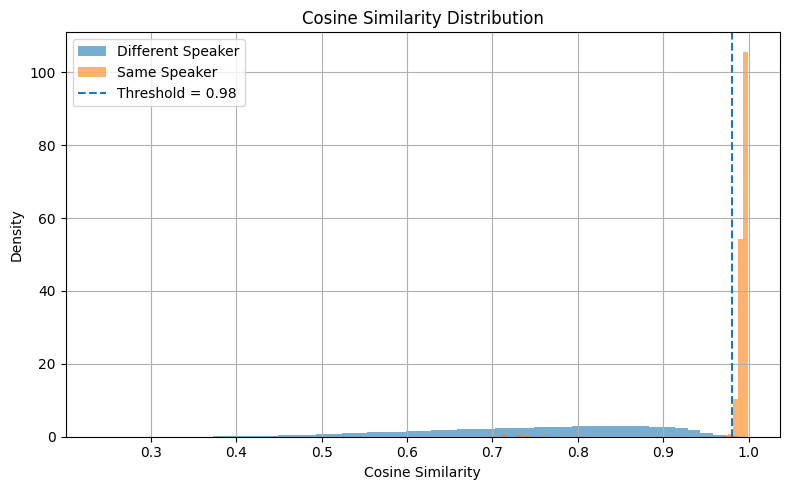

>> [OK] Similarity distribution plot saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/plots_bestThreshold_0.98/cosine_similarity_distribution_density.png


In [19]:
same_scores = similarity_df[similarity_df["same_speaker"] == True]["cosine_similarity"]
different_scores = similarity_df[similarity_df["same_speaker"] == False]["cosine_similarity"]

plt.figure(figsize=(8, 5))

plt.hist(different_scores, bins=50, alpha=0.6, label="Different Speaker", density=True)
plt.hist(same_scores, bins=50, alpha=0.6, label="Same Speaker", density=True)

plt.axvline(best_threshold, linestyle="--", label=f"Threshold = {best_threshold:.2f}")

plt.title("Cosine Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

distribution_dens_plot_path = PLOTS_PATH / "cosine_similarity_distribution_density.png"
plt.savefig(distribution_dens_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f">> [OK] Similarity distribution plot saved to: {distribution_dens_plot_path.resolve()}")

## 8. Confusion Matrix

This section evaluates the final selected threshold using a confusion matrix. The matrix shows how many pairs were correctly or incorrectly classified as same-speaker or different-speaker pairs.

The raw confusion matrix is useful because it shows the actual number of true positives, true negatives, false positives, and false negatives. This makes it easier to see the real number of mistakes made by the system. This is important because the pairwise comparison setup creates many more different-speaker pairs than same-speaker pairs. As a result, accuracy alone does not fully describe the model’s behaviour.

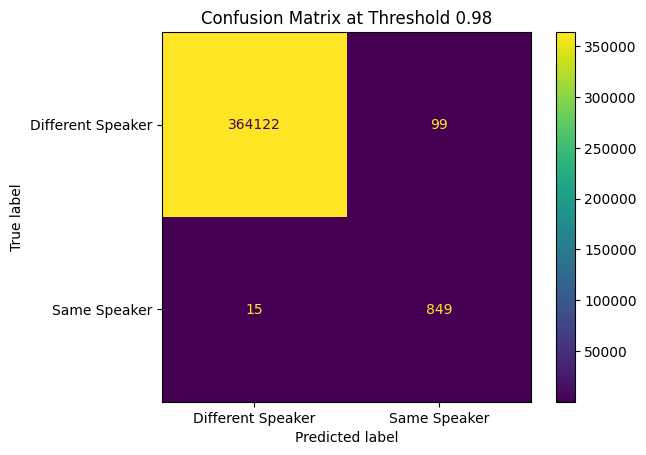

>> [OK] Confusion matrix saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/plots_bestThreshold_0.98/confusion_matrix.png


In [20]:
# True labels
y_true = similarity_df["same_speaker"]

# Predicted labels using the best threshold
y_pred = similarity_df["cosine_similarity"] >= best_threshold

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Different Speaker", "Same Speaker"]
)

disp.plot()

plt.title(f"Confusion Matrix at Threshold {best_threshold:.2f}")

cm_path = PLOTS_PATH / "confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")

plt.show()

print(f">> [OK] Confusion matrix saved to: {cm_path.resolve()}")

### 8.1 Normalised Confusion Matrix

The normalised confusion matrix shows the proportion of correct and incorrect predictions within each true class. This makes the results easier to compare when the number of same-speaker and different-speaker pairs is very different.

This plot is useful because it reduces the visual effect of class imbalance. It shows how well the model performs for each class separately rather than focusing only on the raw number of comparisons.

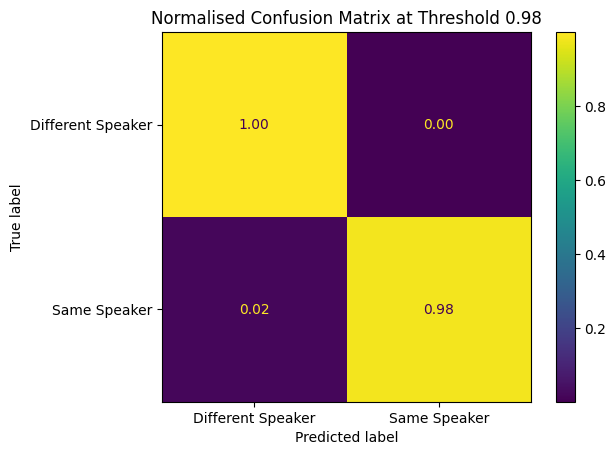

>> [OK] Confusion matrix saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/plots_bestThreshold_0.98/normalised_confusion_matrix.png


In [21]:
# Create a normalised confusion matrix
normalised_cm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

# Display the normalised matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=normalised_cm,
    display_labels=["Different Speaker", "Same Speaker"]
)

disp.plot(values_format=".2f")

plt.title(f"Normalised Confusion Matrix at Threshold {best_threshold:.2f}")

cm_norm_path = PLOTS_PATH / "normalised_confusion_matrix.png"
plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")

plt.show()

print(f">> [OK] Confusion matrix saved to: {cm_norm_path.resolve()}")

### 8.2 Evaluation Metrics

This subsection calculates additional metrics from the confusion matrix:

- `Accuracy` shows the overall proportion of correct predictions
- `Precision` shows how often predicted same-speaker pairs were actually correct
- `Recall` measures how many true same-speaker pairs were successfully detected 
- `Specificity` measures how many different-speaker pairs were correctly rejected
- `F1 score` combines precision and recall into a single balanced measure.

These metrics are useful because looking at multiple metrics gives a clearer view of performance than accuracy alone.

In [22]:
# Extract confusion matrix values
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1_score_value = 2 * (precision * recall) / (precision + recall)

print(f">> Accuracy: {accuracy:.6f}")
print(f">> Precision: {precision:.6f}")
print(f">> Recall: {recall:.6f}")
print(f">> Specificity: {specificity:.6f}")
print(f">> F1 Score: {f1_score_value:.6f}")

>> Accuracy: 0.999688
>> Precision: 0.895570
>> Recall: 0.982639
>> Specificity: 0.999728
>> F1 Score: 0.937086


## 9. PCA and t-SNE Visualisation

This section visualises the speaker embeddings for around 20 selected speakers. PCA and t-SNE are used to project the embeddings into two dimensions so they can be shown on a plot. These plots are used as a visual check to see whether embeddings from the same speaker appear near each other.

If samples from the same speaker form clusters, this suggests that the model is capturing useful speaker-related patterns in the embeddings.

In [23]:
# Load saved speaker embeddings
print(f">> [OK] Embeddings loaded from: {embedding_output_path.resolve()}")
print(f">> [INFO] Total embeddings: {len(embedding_df)}")
print(f">> [INFO] Total speakers: {embedding_df['speaker_id'].nunique()}")

>> [OK] Embeddings loaded from: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/speaker_embeddings.pkl
>> [INFO] Total embeddings: 855
>> [INFO] Total speakers: 284


In [24]:
# Select around 20 speakers
selected_speakers = embedding_df["speaker_id"].unique()[:20]

# Keep only rows belonging to those speakers
subset_df = embedding_df[embedding_df["speaker_id"].isin(selected_speakers)].copy()

print(f">> [OK] Selected speakers: {len(selected_speakers)}")
print(f">> [INFO] Selected embeddings: {len(subset_df)}")

>> [OK] Selected speakers: 20
>> [INFO] Selected embeddings: 60


In [25]:
# Stack all embeddings into one NumPy array
X = np.stack(subset_df["embedding"].values)

# Speaker IDs will be used as labels in the plots
speaker_labels = subset_df["speaker_id"].values

### 9.1. PCA Plot

PCA reduces the speaker embeddings into two dimensions by keeping the main directions of variation in the embedding space.

The plot below shows that some samples from the same speaker are grouped close together. This suggests that the embeddings contain information related to speaker identity. However, not all speakers are clearly separated, and some overlap is visible.

This is expected because PCA is a linear method and cannot show all the information from the original high-dimensional embeddings. For this reason, the PCA plot is useful as a general visual check, but it is limited for detailed speaker separation.

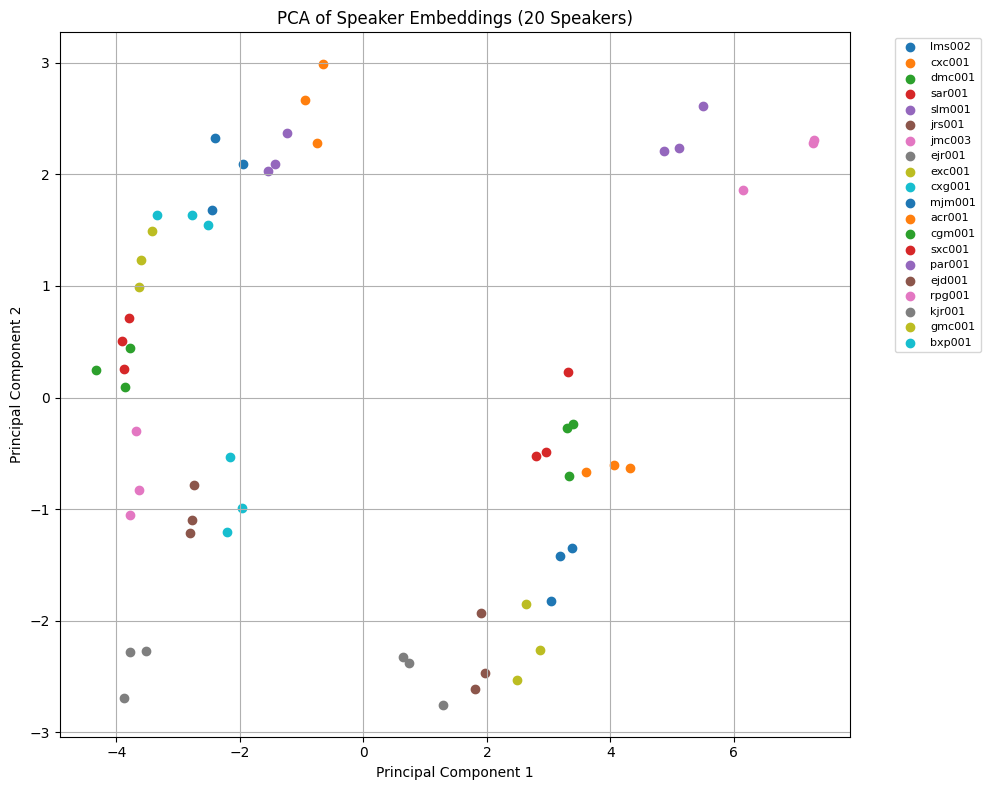

>> [OK] PCA plot saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/plots_bestThreshold_0.98/pca_20_speakers.png


In [26]:
# Reduce embeddings to 2 dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Create PCA plot
plt.figure(figsize=(10, 8))

# Loop through each selected speaker
for speaker_id in selected_speakers:
    # Find the rows that belong to the current speaker
    mask = speaker_labels == speaker_id
    
    # Plot the points for that speaker
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=speaker_id
    )

plt.title("PCA of Speaker Embeddings (20 Speakers)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.grid()

pca_plot_path = PLOTS_PATH / "pca_20_speakers.png"
plt.savefig(pca_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f">> [OK] PCA plot saved to: {pca_plot_path.resolve()}")

### 9.2 t-SNE plot

t-SNE, like PCA, reduces the speaker embeddings into two dimensions for visualisation. However, these dimensions do not directly represent specific speech features such as pitch, accent, gender, or speaker identity.

Instead, the plot is interpreted by looking at the relative positions of the points. Points that appear close together have similar embeddings, while points that are far apart are less similar.

In this plot, most samples from the same speaker form compact groups, suggesting that the WavLM embeddings capture speaker-specific characteristics well. Compared to PCA, t-SNE shows clearer local clustering in the embedding space.

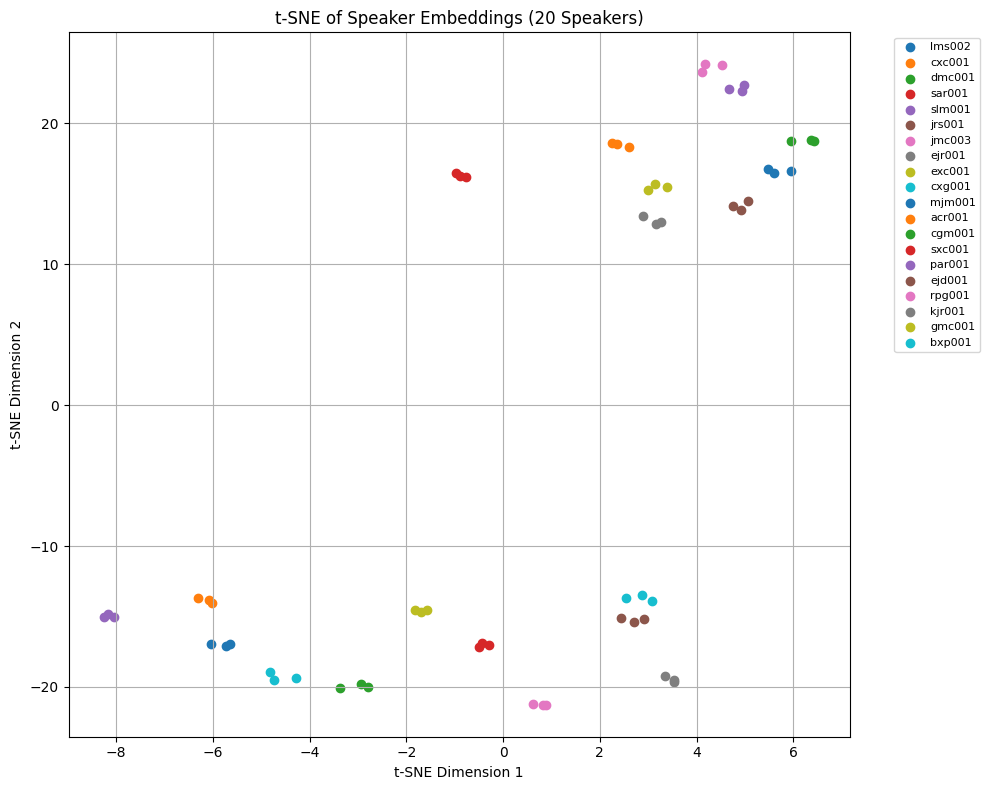

>> [OK] t-SNE plot saved to: /home/davidf_wsl/ARI5121 - AppliedNLP_Project/SpeechProcessing/results/plots_bestThreshold_0.98/tsne_20_speakers.png


In [27]:
# Reduce embeddings to 2 dimensions using t-SNE
# Perplexity 10 is reasonable here for a small subset
tsne = TSNE(
    n_components=2,
    perplexity=10,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X)

# Create t-SNE plot
plt.figure(figsize=(10, 8))

# Loop through each selected speaker
for speaker_id in selected_speakers:
    # Find the rows that belong to the current speaker
    mask = speaker_labels == speaker_id
    
    # Plot the points for that speaker
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        label=speaker_id
    )

plt.title("t-SNE of Speaker Embeddings (20 Speakers)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.grid()

tsne_plot_path = PLOTS_PATH / "tsne_20_speakers.png"
plt.savefig(tsne_plot_path, dpi=300, bbox_inches="tight")

plt.show()

print(f">> [OK] t-SNE plot saved to: {tsne_plot_path.resolve()}")

## 10. End

In [28]:
elapsed_time = time.time() - start_time
print(f">> Elapsed Time: {elapsed_time:.3f} seconds | {elapsed_time / 60:.3f} minutes | {elapsed_time / 3600:.3f} hours")

>> Elapsed Time: 3933.611 seconds | 65.560 minutes | 1.093 hours
